In [1]:
import pandas as pd
from pycaret.clustering import *

In [7]:
import pycaret
from pycaret.datasets import get_data

In [8]:
df = get_data('jewellery')

,Age,Income,SpendingScore,Savings
0,58,77769,0.791329,6559.829923
1,59,81799,0.791082,5417.661426
2,62,74751,0.702657,9258.992965
3,59,74373,0.765680,7346.334504
4,87,17760,0.348778,16869.507130


In [ ]:
# preprocess data

clu_exp = setup(data=df, session_id=42, normalize=True, normalize_method='zscore')

# (function) def setup(
#     data: DATAFRAME_LIKE | None = None,
#     data_func: (() -> DATAFRAME_LIKE) | None = None,
#     index: bool | int | str | Any = True,
#     ordinal_features: Dict[str, list] | None = None,
#     numeric_features: List[str] | None = None,
#     categorical_features: List[str] | None = None,
#     date_features: List[str] | None = None,
#     text_features: List[str] | None = None,
#     ignore_features: List[str] | None = None,
#     keep_features: List[str] | None = None,
#     preprocess: bool = True,
#     create_date_columns: List[str] = ["day", "month", "year"],
#     imputation_type: str | None = "simple",
#     numeric_imputation: str = "mean",
#     categorical_imputation: str = "mode",
#     text_features_method: str = "tf-idf",
#     max_encoding_ohe: int = -1,
#     encoding_method: Any | None = None,
#     rare_to_value: float | None = None,
#     rare_value: str = "rare",
#     polynomial_features: bool = False,
#     polynomial_degree: int = 2,
#     low_variance_threshold: float | None = None,
#     remove_multicollinearity: bool = False,
#     multicollinearity_threshold: float = 0.9,
#     bin_numeric_features: List[str] | None = None,
#     remove_outliers: bool = False,
#     outliers_method: str = "iforest",
#     outliers_threshold: float = 0.05,
#     transformation: bool = False,
#     transformation_method: str = "yeo-johnson",
#     normalize: bool = False,
#     normalize_method: str = "zscore",
#     pca: bool = False,
#     pca_method: str = "linear",
#     pca_components: int | float | str | None = None,
#     custom_pipeline: Any | None = None,
#     custom_pipeline_position: int = -1,
#     n_jobs: int | None = -1,
#     use_gpu: bool = False,
#     html: bool = True,
#     session_id: int | None = None,
#     system_log: bool | str | Logger = True,
#     log_experiment: bool | str | BaseLogger | List[str | BaseLogger] = False,
#     experiment_name: str | None = None,
#     experiment_custom_tags: Dict[str, Any] | None = None

,Description,Value
0,Session id,42
1,Original data shape,"(505, 4)"
2,Transformed data shape,"(505, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,Normalize,True
9,Normalize method,zscore


In [ ]:
kmeans = create_model('kmeans')

# (function) def create_model(
#     model: str | Any,
#     num_clusters: int = 4,
#     ground_truth: str | None = None,
#     round: int = 4,
#     fit_kwargs: dict | None = None,
#     verbose: bool = True,
#     experiment_custom_tags: Dict[str, Any] | None = None,
#     engine: str | None = None,
#     **kwargs: Any
# ) -> Any

print(kmeans)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.7581,1611.2647,0.3743,0,0,0


KMeans(n_clusters=4, random_state=42)


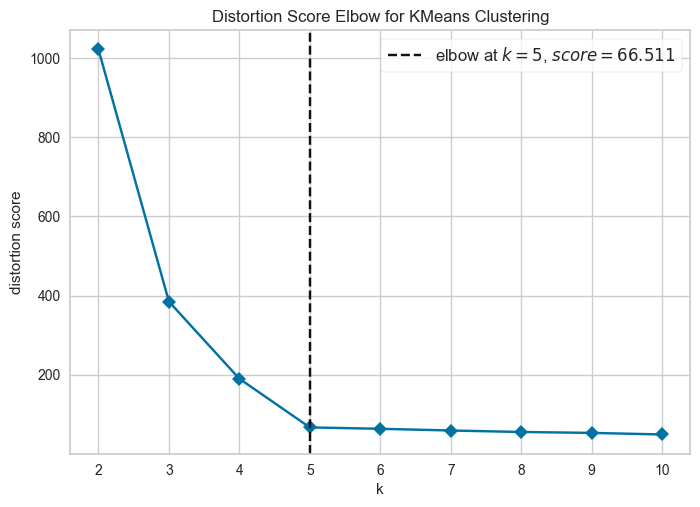

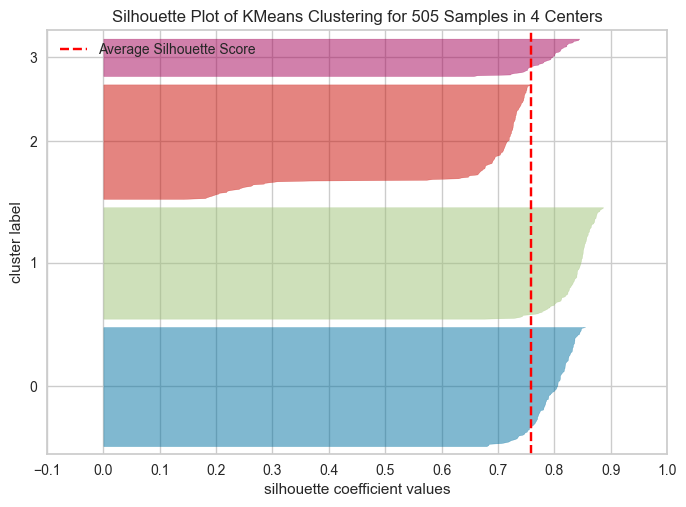

In [ ]:
# (function) def plot_model(
#     model: Any,
#     plot: str = "cluster",
#     feature: str | None = None,
#     label: bool = False,
#     scale: float = 1,
#     save: bool = False,
#     display_format: str | None = None
# ) -> (str | None)

# Visualize - Elbow Plot to find optimal 'k'
# The elbow is the point of inflection, suggesting the best number of clusters.
plot_model(kmeans, plot='elbow') 

# Visualize - Silhouette Plot (measures separation distance)
# The closer the overall average score is to 1, the better.
plot_model(kmeans, plot='silhouette')

# Visualize - Cluster Plot (2D PCA projection)
# Visualizes the clusters after dimensionality reduction to 2D using PCA.
plot_model(kmeans, plot='cluster')

In [12]:
clustered_data = assign_model(kmeans)

In [13]:
print("\n--- Data with Assigned Cluster Labels ---")
print(clustered_data.head())


--- Data with Assigned Cluster Labels ---
   Age  Income  SpendingScore       Savings    Cluster
0   58   77769       0.791329   6559.830078  Cluster 0
1   59   81799       0.791082   5417.661621  Cluster 0
2   62   74751       0.702657   9258.993164  Cluster 0
3   59   74373       0.765680   7346.334473  Cluster 0
4   87   17760       0.348778  16869.507812  Cluster 1
